In [1]:
import sys, os
import geopandas as gpd
import pandas as pd
import seaborn as sns

sys.path.append('/home/dnash/repos/eaton_scripps_CO_ARs/modules')
from plot_trajectory_maps import subset_gdf_to_plot

In [6]:
# Load trajectory GeoJSON data
gdf = gpd.read_file("/home/dnash/repos/eaton_scripps_CO_ARs/out/trajectories.geojson")
gdf.crs = 'epsg:3857'
gdf = gdf.set_index(pd.to_datetime(gdf['start_date']))

ssn = 'MJJASO'
ARDT = 'tARget'
ar = True
region_lst = ['northern_upper_CO', 'southern_upper_CO', 'rio_grande', 'eastern_CO']

subset_gdf = subset_gdf_to_plot(gdf, ARDT, ssn, ar, region=None, basin=None, HUC8=None)

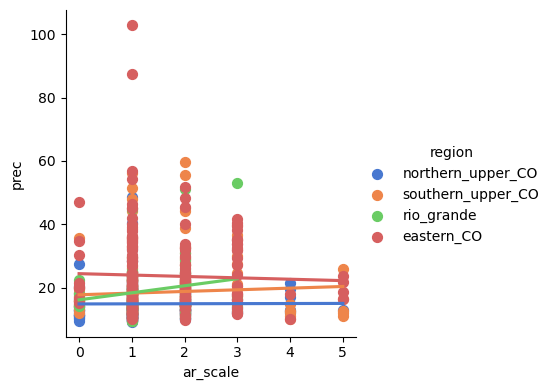

In [7]:
# Show the results of a linear regression within each dataset
sns.lmplot(
    data=subset_gdf, x="ar_scale", y="prec", hue="region",
    palette="muted", ci=None,
    height=4, scatter_kws={"s": 50, "alpha": 1}
)